# What is t-SNE?

t-SNE (t-distributed Stochastic Neighbor Embedding) is a nonlinear dimensionality reduction technique used to visualize high-dimensional data.

Like PCA, t-SNE reduces thousands of molecular features into two or three dimensions.

However, unlike PCA, t-SNE focuses on preserving the local relationships between molecules.

As a result, molecules that are structurally similar tend to form well-defined clusters in the visualization.

## Why Do We Need t-SNE?

PCA is a linear dimensionality reduction technique.

Although PCA is computationally efficient, it cannot always capture complex nonlinear relationships present in molecular datasets.

Chemical datasets often contain intricate structural patterns that cannot be represented accurately using straight-line transformations.

t-SNE is specifically designed to preserve local similarities, making it much better at revealing clusters of related molecules.

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

from sklearn.manifold import TSNE

import matplotlib.pyplot as plt

In [3]:
# Load the ESOL DataSet
df = pd.read_csv("esol_raw.csv")

df = df[["smiles", "measured log solubility in mols per litre"]]

df.head()

,smiles,measured log solubility in mols per litre
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77
1,Cc1occc1C(=O)Nc2ccccc2,-3.30
2,CC(C)=CCCC(C)=CC(=O),-2.06
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87
4,c1ccsc1,-1.33


In [4]:
# Convert SMIlES to RDKit Molecules

df["Mol"] = df["smiles"].apply(Chem.MolFromSmiles)

df = df[df["Mol"].notnull()]

print("Number of molecules:", len(df))

Number of molecules: 1128


In [5]:
# Generate Morgan Fingerprint

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

fingerprints = []

for mol in df["Mol"]:
    fp = morgan_gen.GetFingerprintAsNumPy(mol)
    fingerprints.append(fp)

X = np.array(fingerprints)

print("Fingerprint Matrix Shape:", X.shape)

Fingerprint Matrix Shape: (1128, 2048)


In [6]:
# Apply t-SNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X)

print(X_tsne.shape)

(1128, 2)


In [7]:
# Add t-SNE Coordinates

df["tSNE1"] = X_tsne[:, 0]
df["tSNE2"] = X_tsne[:, 1]

df.head()

,smiles,measured log solubility in mols per litre,Mol,tSNE1,tSNE2
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77,<rdkit.Chem.rdchem.Mol object at 0x0000025A89C...,17.341150,-14.992429
1,Cc1occc1C(=O)Nc2ccccc2,-3.30,<rdkit.Chem.rdchem.Mol object at 0x0000025A89C...,-9.601786,27.361353
2,CC(C)=CCCC(C)=CC(=O),-2.06,<rdkit.Chem.rdchem.Mol object at 0x0000025A89C...,-16.775101,-14.545948
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87,<rdkit.Chem.rdchem.Mol object at 0x0000025A89C...,23.198023,16.776917
4,c1ccsc1,-1.33,<rdkit.Chem.rdchem.Mol object at 0x0000025A89C...,5.653068,3.095815


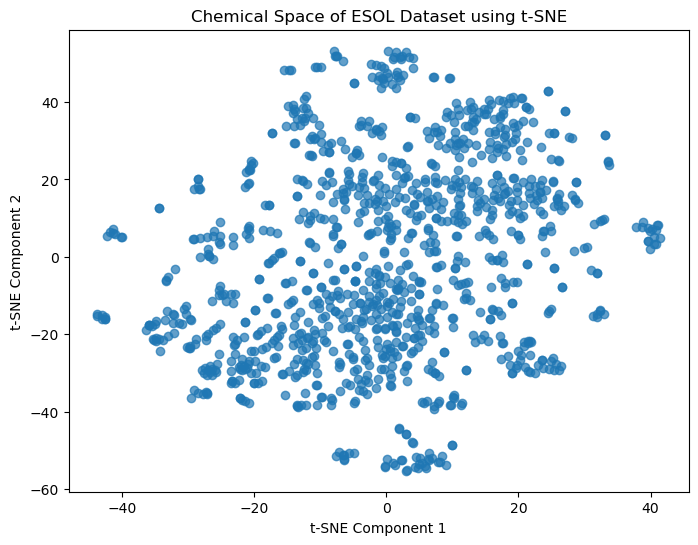

In [8]:
# Visualize the Chemical Space

plt.figure(figsize=(8,6))

plt.scatter(
    df["tSNE1"],
    df["tSNE2"],
    alpha=0.7
)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("Chemical Space of ESOL Dataset using t-SNE")

plt.show()

## Interpretation

The t-SNE plot represents the chemical space of the ESOL dataset.

Each point corresponds to one molecule.

Unlike PCA, which preserves overall variance, t-SNE preserves local similarities between molecules.

As a result, structurally similar molecules tend to form distinct clusters, making it easier to identify molecular families and neighborhoods.

The distances between distant clusters should not be interpreted quantitatively because t-SNE primarily focuses on preserving local relationships rather than global distances.

Therefore, t-SNE is particularly useful for exploring molecular diversity, identifying clusters, and visualizing structurally related compounds.